# 06 — `psd`: power spectral density

`pp, ff = dsp.psd(x, fs)` returns the power spectrum and frequency
axis. We then integrate `pp` over named bands ourselves — the
companion helper is currently in flux upstream.

pp: (1, 1, 1025) ff: (1025,)


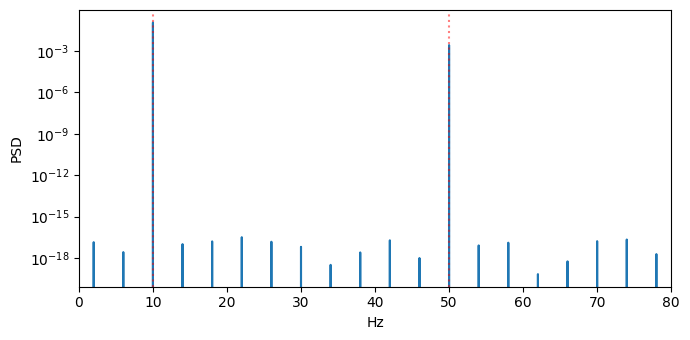

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import scitex_dsp as dsp
%matplotlib inline

xx, tt, fs = dsp.demo_sig(sig_type="periodic", batch_size=1, n_chs=1,
                          t_sec=4, fs=512, freqs_hz=[10, 50])
pp, ff = dsp.psd(xx, fs=fs)
pp, ff = np.asarray(pp), np.asarray(ff)
print("pp:", pp.shape, "ff:", ff.shape)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(ff, pp[0, 0])
for f0 in (10, 50):
    ax.axvline(f0, color="red", ls=":", alpha=0.5)
ax.set_xlabel("Hz"); ax.set_ylabel("PSD"); ax.set_xlim(0, 80)
fig.tight_layout()
plt.show()


## Per-band integrated power

In [2]:
bands = {"theta": (4, 8), "alpha": (8, 13),
         "beta": (13, 30), "gamma": (30, 80)}
for name, (lo, hi) in bands.items():
    mask = (ff >= lo) & (ff <= hi)
    power = float(pp[0, 0][mask].sum())
    print(f"{name:>5} {lo:>2}-{hi:>2} Hz : {power:.3g}")

theta  4- 8 Hz : 2.72e-18
alpha  8-13 Hz : 0.11
 beta 13-30 Hz : 8.1e-17
gamma 30-80 Hz : 0.00256
